# Module 4.1 - Visibility Score Methodology Design

Designs the composite visibility scoring methodology: which variables go in, how they are
weighted, and how they are normalized. This is a DESIGN step; the actual sponsor scoring is
implemented in Module 4.2. Every decision is grounded in the Project 3 EDA findings.

**Sponsors:** FedEx, NAPA Auto Parts, McDonald's, Love's Travel Stops. **Season:** 2024 Cup
Series, 36 races, 144 rows.

**EDA facts that shape this design (from Modules 3.1 / 3.2):**
- "Reddit" is a Google Trends proxy (Reddit API returned 403); it and total YouTube views are
  race-level (identical across the four sponsors within a race).
- Only news varies cleanly by sponsor. The one significant performance to visibility link was
  Laps Led to News (r = +0.181, p = 0.030).

Outputs: `output/figures/correlation_matrix_variables.png`,
`data/processed/score_variables.json`, `data/processed/scoring_config.json`.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

FIG = '../output/figures'; PROC = '../data/processed'
os.makedirs(FIG, exist_ok=True)
df = pd.read_csv(f'{PROC}/master_dataset.csv')
print('Loaded', df.shape)

Loaded (144, 22)


## Step 1 - Review candidate variables (correlation matrix)

We have many candidate variables. First we look at how they relate, to spot redundancy.

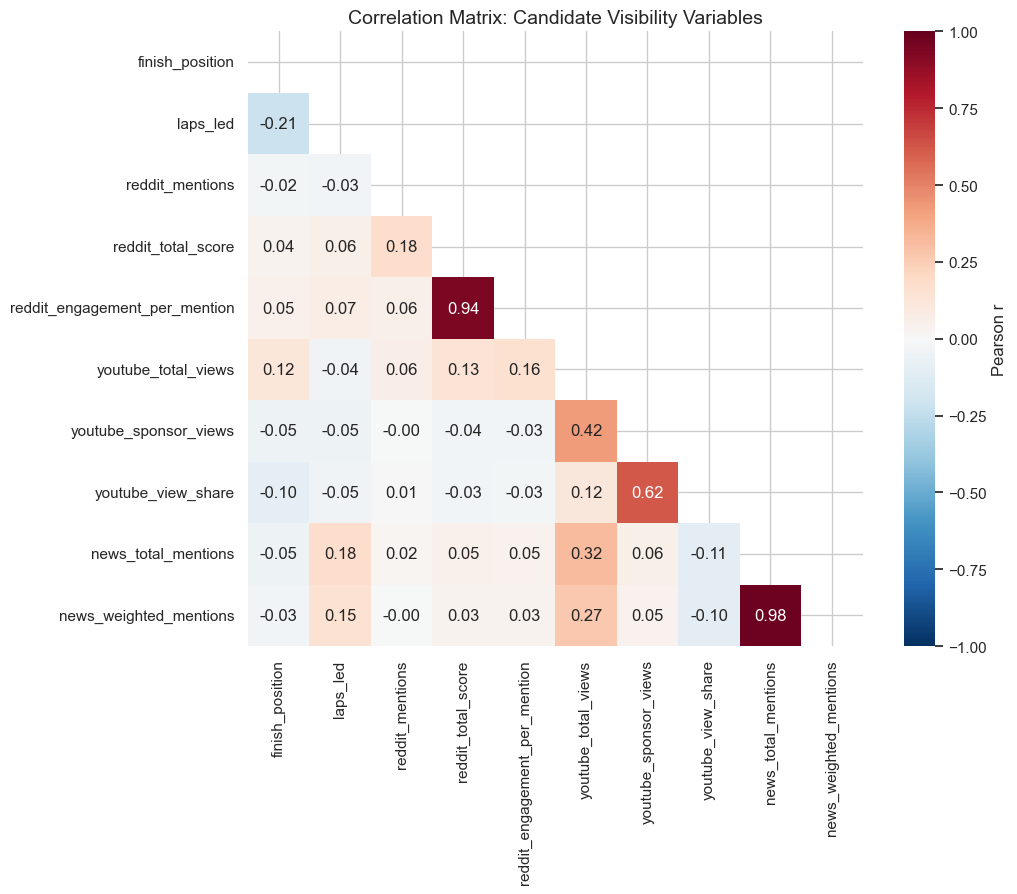

Correlations with finish_position (sorted):
laps_led                        -0.214
youtube_view_share              -0.100
youtube_sponsor_views           -0.052
news_total_mentions             -0.048
news_weighted_mentions          -0.032
reddit_mentions                 -0.024
reddit_total_score               0.038
reddit_engagement_per_mention    0.050
youtube_total_views              0.124
finish_position                  1.000


In [2]:
candidates = ['finish_position','laps_led','reddit_mentions','reddit_total_score',
    'reddit_engagement_per_mention','youtube_total_views','youtube_sponsor_views',
    'youtube_view_share','news_total_mentions','news_weighted_mentions']
corr = df[candidates].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation Matrix: Candidate Visibility Variables', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIG}/correlation_matrix_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print('Correlations with finish_position (sorted):')
print(corr['finish_position'].round(3).sort_values().to_string())

## Step 2 - Multicollinearity check

Variable pairs with |r| >= 0.8 measure nearly the same thing. We keep only one from each pair.

In [3]:
def find_multicollinearity(corr_matrix, threshold=0.8):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append({'var1': cols[i], 'var2': cols[j], 'correlation': round(r, 3)})
    return pairs

for p in find_multicollinearity(corr, 0.8):
    print(f" {p['var1']:32s} & {p['var2']:32s} r = {p['correlation']:+.3f}")

 reddit_total_score               & reddit_engagement_per_mention    r = +0.941
 news_total_mentions              & news_weighted_mentions           r = +0.978


## Step 3 - Reliability check (coverage and sponsor-specificity)

A variable must be measurable consistently. We flag sparse variables (few non-zero rows) and
note which vary by sponsor within a race (sponsor-specific) versus which are race-level.

In [4]:
rel = []
for c in candidates:
    nz = int((df[c] > 0).sum())
    sponsor_specific = df.groupby('race_number')[c].nunique().max() > 1
    rel.append({'variable': c, 'nonzero_rows': nz, 'coverage_pct': round(nz/len(df)*100, 1),
                'sponsor_specific': sponsor_specific})
rel_df = pd.DataFrame(rel)
print(rel_df.to_string(index=False))

                     variable  nonzero_rows  coverage_pct  sponsor_specific
              finish_position           144         100.0              True
                     laps_led            67          46.5              True
              reddit_mentions           104          72.2             False
           reddit_total_score             9           6.2              True
reddit_engagement_per_mention             9           6.2              True
          youtube_total_views           104          72.2             False
        youtube_sponsor_views             4           2.8              True
           youtube_view_share             4           2.8              True
          news_total_mentions            89          61.8              True
       news_weighted_mentions            89          61.8              True


## Step 4 - Decision matrix (relevance / independence / reliability)

Scores 1-5 per criterion, grounded in the checks above and the EDA. Selected variables are
the core of the score; excluded ones are redundant, too sparse, or not sponsor-specific.

In [5]:
decision = pd.DataFrame([
 ['finish_position', 5,5,5,'YES','Direct performance measure; 100% coverage; sponsor-specific'],
 ['laps_led', 4,3,5,'YES','Race dominance; distinct from finish (r=-0.21)'],
 ['reddit_mentions', 4,4,4,'YES','Cleanest social metric (score/engagement too sparse, 9/144)'],
 ['youtube_sponsor_views',5,4,2,'YES','Sponsor-specific video exposure; sparse (4/144) - flagged'],
 ['news_weighted_mentions',5,4,4,'YES','Quality-weighted media; sponsor-specific; the real EDA signal'],
 ['reddit_total_score',3,1,2,'NO','Sparse (9/144); redundant (r=0.94 with engagement)'],
 ['reddit_engagement_per_mention',3,2,2,'NO','Sparse (9/144); volatile'],
 ['youtube_total_views',4,2,5,'NO','Race-level, not sponsor-specific'],
 ['youtube_view_share',3,2,2,'NO','Derivative of sponsor_views; sparse (4/144)'],
 ['news_total_mentions',4,2,4,'NO','Redundant with weighted (r=0.98)'],
], columns=['variable','relevance','independence','reliability','include','rationale'])
print(decision.to_string(index=False))

                     variable  relevance  independence  reliability include                                                     rationale
              finish_position          5             5            5     YES   Direct performance measure; 100% coverage; sponsor-specific
                     laps_led          4             3            5     YES                Race dominance; distinct from finish (r=-0.21)
              reddit_mentions          4             4            4     YES   Cleanest social metric (score/engagement too sparse, 9/144)
        youtube_sponsor_views          5             4            2     YES     Sponsor-specific video exposure; sparse (4/144) - flagged
       news_weighted_mentions          5             4            4     YES Quality-weighted media; sponsor-specific; the real EDA signal
           reddit_total_score          3             1            2      NO            Sparse (9/144); redundant (r=0.94 with engagement)
reddit_engagement_per_mention     

## Step 5 - Final variable configuration (`score_variables.json`)

In [6]:
SCORE_VARIABLES = {
 'performance': {
   'finish_position': {'description':'Race finishing position (will be inverted)','direction':'inverse','weight_category':'race_performance'},
   'laps_led': {'description':'Number of laps leading the race','direction':'direct','weight_category':'race_performance'},
 },
 'social': {
   'reddit_mentions': {'description':'r/NASCAR mentions (Google Trends proxy; race-level)','direction':'direct','weight_category':'social_engagement'},
   'youtube_sponsor_views': {'description':'Views on sponsor-relevant YouTube videos (sparse)','direction':'direct','weight_category':'social_engagement'},
 },
 'media': {
   'news_weighted_mentions': {'description':'Quality-weighted news article mentions','direction':'direct','weight_category':'media_coverage'},
 },
 'special_events': {
   'is_win': {'description':'Binary flag: 1 if finish_position == 1','direction':'direct','weight_category':'special_events'},
   'is_playoff': {'description':'Binary flag: 1 if race_number >= 27','direction':'direct','weight_category':'special_events'},
 },
}
with open(f'{PROC}/score_variables.json','w') as f:
    json.dump(SCORE_VARIABLES, f, indent=2)
n = sum(len(v) for v in SCORE_VARIABLES.values())
print(f'Saved score_variables.json - {n} variables selected')

Saved score_variables.json - 7 variables selected


## Step 6 - Weighting configuration (`scoring_config.json`)

Hybrid approach: category weights come from industry frameworks (Playbook Sports: on-field
performance 30-40%, media 25-35%, social 20-30%, activation 10-20%, which we redistribute
since we cannot measure activation), refined by our EDA. Note our EDA gives Media (news) the
single highest variable weight (30%), which matches the finding that news is the most reliable
sponsor-level signal.

In [7]:
WEIGHT_CONFIG = {
 'category_weights': {'race_performance':0.40,'media_coverage':0.30,'social_engagement':0.20,'special_events':0.10},
 'variable_weights_within_category': {
   'race_performance': {'finish_position':0.70,'laps_led':0.30},
   'media_coverage': {'news_weighted_mentions':1.00},
   'social_engagement': {'reddit_mentions':0.50,'youtube_sponsor_views':0.50},
   'special_events': {'is_win':0.60,'is_playoff':0.40},
 },
}
def effective_weights(cfg):
    eff = {}
    for cat, vw in cfg['variable_weights_within_category'].items():
        cat_w = cfg['category_weights'][cat]
        for v, w in vw.items():
            eff[v] = round(cat_w * w, 4)
    return eff
eff = effective_weights(WEIGHT_CONFIG)
print('Effective variable weights:')
for v, w in sorted(eff.items(), key=lambda x:-x[1]):
    print(f' {v:24s} {w*100:5.1f}%')
print(f' {"TOTAL":24s} {sum(eff.values())*100:5.1f}%')

SCORING_CONFIG = {'version':'1.0','created_date':'2026-07-21',
  'category_weights':WEIGHT_CONFIG['category_weights'], 'variables':{}}
# build variables block with metadata
transform = {'finish_position':'invert_position','laps_led':'normalize','news_weighted_mentions':'normalize',
             'reddit_mentions':'normalize','youtube_sponsor_views':'log_normalize','is_win':'binary','is_playoff':'binary'}
direction = {'finish_position':'inverse'}
cat_of = {v:meta['weight_category'] for grp in SCORE_VARIABLES.values() for v,meta in grp.items()}
within = {v:w for cat in WEIGHT_CONFIG['variable_weights_within_category'].values() for v,w in cat.items()}
SCORING_CONFIG['variables'] = {v:{'category':cat_of[v],'weight_within_category':within[v],
    'effective_weight':eff[v],'direction':direction.get(v,'direct'),'transform':transform[v]} for v in eff}
with open(f'{PROC}/scoring_config.json','w') as f:
    json.dump(SCORING_CONFIG, f, indent=2)
print('Saved scoring_config.json')

Effective variable weights:
 news_weighted_mentions    30.0%
 finish_position           28.0%
 laps_led                  12.0%
 reddit_mentions           10.0%
 youtube_sponsor_views     10.0%
 is_win                     6.0%
 is_playoff                 4.0%
 TOTAL                    100.0%
Saved scoring_config.json


## Step 7 - Normalization method (min-max to 0-100) and tests

Method: min-max normalization to a 0-100 scale, computed season-wide (across all rows).
Direct variables: higher is better. Inverse variables (finish position): lower is better.
Special handling: binary flags scale 0/1 to 0/100; YouTube views use log(x+1) first to tame
extreme outliers.

In [8]:
def normalize_to_100(series, direction='direct'):
    lo, hi = series.min(), series.max()
    if hi == lo:
        return pd.Series([50.0]*len(series), index=series.index) # no differentiation
    if direction == 'direct':
        return (series - lo) / (hi - lo) * 100
    elif direction == 'inverse':
        return (hi - series) / (hi - lo) * 100
    raise ValueError(f"direction must be 'direct' or 'inverse', got {direction!r}")

def prepare_finish_position(s):
    return normalize_to_100(s, direction='inverse') # P1 -> ~100, worst -> ~0

def prepare_binary(s):
    return s * 100 # 0 -> 0, 1 -> 100

def prepare_youtube_views(s, use_log=True):
    return normalize_to_100(np.log1p(s), 'direct') if use_log else normalize_to_100(s, 'direct')

# Tests
print('Finish positions [1,5,10,20,40] inverse ->',
      normalize_to_100(pd.Series([1,5,10,20,40]), 'inverse').round(1).tolist())
print('Binary [0,0,1,0] ->', prepare_binary(pd.Series([0,0,1,0])).tolist())
print('YouTube [0,1e3,1e4,1e5,1e6] log ->',
      prepare_youtube_views(pd.Series([0,1e3,1e4,1e5,1e6])).round(1).tolist())

Finish positions [1,5,10,20,40] inverse -> [100.0, 89.7, 76.9, 51.3, 0.0]
Binary [0,0,1,0] -> [0, 0, 100, 0]
YouTube [0,1e3,1e4,1e5,1e6] log -> [0.0, 50.0, 66.7, 83.3, 100.0]


### End-to-end normalization test on a small sample

In [9]:
test = pd.DataFrame({
 'race_number':[1,1,2,2,3,3],'sponsor':['FedEx','NAPA','FedEx','NAPA','FedEx','NAPA'],
 'finish_position':[1,15,8,3,25,2],'laps_led':[150,0,20,80,0,100],
 'reddit_mentions':[45,10,15,35,5,40],'youtube_sponsor_views':[500000,50000,100000,300000,25000,400000],
 'news_weighted_mentions':[12,3,5,10,2,11]})
test['is_win'] = (test['finish_position']==1).astype(int)
test['is_playoff'] = (test['race_number']>=27).astype(int)
out = test[['sponsor']].copy()
out['finish_n'] = prepare_finish_position(test['finish_position'])
out['laps_n'] = normalize_to_100(test['laps_led'],'direct')
out['reddit_n'] = normalize_to_100(test['reddit_mentions'],'direct')
out['youtube_n'] = prepare_youtube_views(test['youtube_sponsor_views'])
out['news_n'] = normalize_to_100(test['news_weighted_mentions'],'direct')
out['win_n'] = prepare_binary(test['is_win'])
out['playoff_n'] = prepare_binary(test['is_playoff'])
print(out.round(1).to_string(index=False))
print('\nAll normalized columns are on the same 0-100 scale and ready for weighting (Module 4.2).')

sponsor  finish_n  laps_n  reddit_n  youtube_n  news_n  win_n  playoff_n
  FedEx     100.0   100.0     100.0      100.0   100.0    100          0
   NAPA      41.7     0.0      12.5       23.1    10.0      0          0
  FedEx      70.8    13.3      25.0       46.3    30.0      0          0
   NAPA      91.7    53.3      75.0       82.9    80.0      0          0
  FedEx       0.0     0.0       0.0        0.0     0.0      0          0
   NAPA      95.8    66.7      87.5       92.6    90.0      0          0

All normalized columns are on the same 0-100 scale and ready for weighting (Module 4.2).


## Aggregation method (design decision)

Weekly race scores are combined into a season total by **SUM** (not average), because all four
sponsors competed in all 36 races (no missing-data bias) and sponsors care about total exposure
delivered over the season. Theoretical max = 100 * 36 = 3600 if a sponsor scored perfectly every
race. This is applied in Module 4.2.